# Tutorial 4: Galacticus calling *your* Python functions

The tutorials so far called from Python *into* Galacticus. Some Galacticus
methods invert the relationship: they take a **function** as an argument —
an integrand, a cross-section — and call it, possibly thousands of times,
from inside the Fortran numerics. The library interface bridges this with
ctypes callbacks: you pass a plain Python callable, and Galacticus's
quadrature engines drive it directly.

Two showcases:

1. volume integrals of arbitrary Python integrands over computational
   domains, with exact analytic checks;
2. integrating a Python-defined cross-section against a black-body
   radiation field.

In [1]:
import os, sys

# Locate the Galacticus library interface. Two supported layouts:
#  * a Galacticus source tree built with
#      make GALACTICUS_BUILD_OPTION=lib libgalacticus.so
#    (galacticus.py at the tree root, the library under galacticus/lib/);
#  * an unpacked binary distribution (the `galacticus/` folder from
#    libgalacticus.tar.bz2, with python/ and lib/ inside it).
# Set GALACTICUS_LIBRARY_PATH to the directory CONTAINING the `galacticus/`
# folder if the auto-detection below does not fit your setup.
root = os.environ.get('GALACTICUS_LIBRARY_PATH',
                      os.path.abspath(os.path.join(os.getcwd(), os.pardir)))
os.chdir(root)   # galacticus.py loads galacticus/lib/libgalacticus.so relative to here
for candidate in (root, os.path.join(root, 'galacticus', 'python')):
    if os.path.exists(os.path.join(candidate, 'galacticus.py')):
        sys.path.insert(0, candidate)
        break
else:
    raise RuntimeError(f"galacticus.py not found under {root} - build the library "
                       "(make GALACTICUS_BUILD_OPTION=lib libgalacticus.so) or set "
                       "GALACTICUS_LIBRARY_PATH")

import numpy as np
import matplotlib.pyplot as plt
import galacticus
print("Galacticus library interface loaded.")

Galacticus library interface loaded.


In [2]:
plt.rcParams.update({'figure.figsize': (7.0, 4.5), 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.3})

## Volume integrators

`computationalDomainVolumeIntegrator` performs quadrature over a spatial
domain in its native coordinate system. Your integrand receives the
position as a 3-element numpy array of **Cartesian** coordinates
(conversion from the domain's own coordinates happens on the Fortran side)
and returns a float.

First, exact checks on the unit cube:

In [3]:
boundaries = np.array([[0.0, 1.0], [0.0, 1.0], [0.0, 1.0]])   # (axis, lower/upper)
integratorCube = galacticus.computationalDomainVolumeIntegratorCartesian3D(boundaries)

print(f"volume                     = {integratorCube.volume():.6f}   (exact: 1)")
print(f"integral of 1              = {integratorCube.integrate(lambda pos: 1.0):.6f}   (exact: 1)")
print(f"integral of x              = {integratorCube.integrate(lambda pos: pos[0]):.6f}   (exact: 0.5)")
print(f"integral of x^2+y^2+z^2    = {integratorCube.integrate(lambda pos: float(np.sum(pos**2))):.6f}   (exact: 1)")

volume                     = 1.000000   (exact: 1)


integral of 1              = 1.000000   (exact: 1)


integral of x              = 0.500000   (exact: 0.5)


integral of x^2+y^2+z^2    = 1.000000   (exact: 1)


Now something with real content: the mass of a
[Plummer sphere](https://en.wikipedia.org/wiki/Plummer_model)
$$\rho(r) = \frac{3M}{4\pi a^3}\left(1+\frac{r^2}{a^2}\right)^{-5/2}$$
inside a spherical shell, where the enclosed-mass profile
$M(<\!R) = M R^3/(R^2+a^2)^{3/2}$ gives us the exact answer. The density
is *defined in Python*; the spherical-coordinates quadrature runs in
Fortran.

In [4]:
massTotal, radiusScale = 1.0e12, 0.05        # Msun, Mpc
def densityPlummer(pos):
    r2 = float(np.sum(pos**2))
    return 3.0*massTotal/(4.0*np.pi*radiusScale**3)*(1.0+r2/radiusScale**2)**(-2.5)

def massEnclosed(R):
    return massTotal*R**3/(R**2+radiusScale**2)**1.5

radiusInner, radiusOuter = 0.01, 0.5         # Mpc
integratorShell = galacticus.computationalDomainVolumeIntegratorSpherical([radiusInner, radiusOuter])
massNumerical = integratorShell.integrate(densityPlummer)
massExact     = massEnclosed(radiusOuter)-massEnclosed(radiusInner)
print(f"shell mass, Galacticus quadrature of Python density: {massNumerical:.6e} Msun")
print(f"shell mass, analytic:                                {massExact:.6e} Msun")
print(f"fractional error: {abs(massNumerical/massExact-1.0):.2e}")
assert np.isclose(massNumerical, massExact, rtol=1.0e-3)

shell mass, Galacticus quadrature of Python density: 9.776424e+11 Msun
shell mass, analytic:                                9.776424e+11 Msun
fractional error: 2.22e-16


## A Python cross-section in a Galacticus radiation field

`radiationField.integrateOverCrossSection(wavelengthRange, crossSection,
node)` integrates a photon cross-section against the field's spectrum —
the operation at the heart of photo-ionization and photo-heating rates.
The cross-section is any Python callable $\sigma(\lambda)$ (wavelengths
in Angstroms).

Two exact properties make good tests: a zero cross-section integrates to
exactly zero, and the integral is linear in $\sigma$. (The `node` argument
lets fields depend on a galaxy's environment; the black-body field ignores
it, so we pass a null handle.)

In [5]:
import ctypes
nodeNull  = ctypes.c_void_p(0)
radiation = galacticus.radiationFieldBlackBody(3.0e4)          # 30,000 K
uvRange   = np.array([100.0, 912.0])                           # ionizing UV, Angstroms

rateZero = radiation.integrateOverCrossSection(uvRange, lambda w: 0.0, nodeNull)
rate1    = radiation.integrateOverCrossSection(uvRange, lambda w: 1.0e-18, nodeNull)
rate2    = radiation.integrateOverCrossSection(uvRange, lambda w: 2.0e-18, nodeNull)
print(f"sigma = 0     ->  {rateZero}   (exactly zero)")
print(f"sigma doubled ->  ratio = {rate2/rate1:.12f}   (exactly 2)")
assert rateZero == 0.0 and np.isclose(rate2/rate1, 2.0, rtol=1.0e-9)

sigma = 0     ->  0.0   (exactly zero)
sigma doubled ->  ratio = 2.000000000000   (exactly 2)


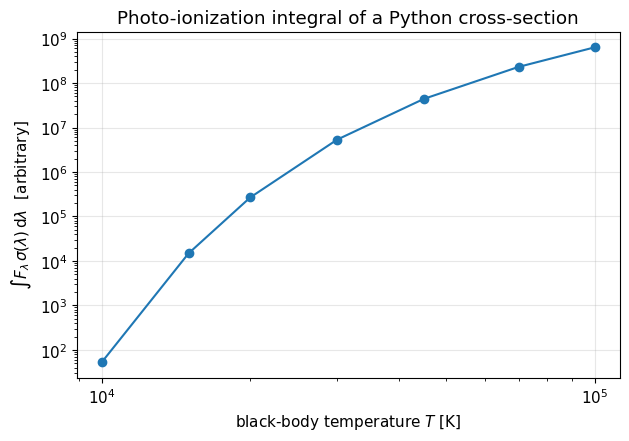

rate(1e5 K)/rate(1e4 K) = 1.209e+07


In [6]:
# A hydrogen-like toy cross-section — zero below the ionization edge,
# falling as (lambda/912A)^3 above threshold energy — integrated against
# black bodies of increasing temperature. Hotter stars are dramatically
# more ionizing; the steep rise mirrors the Wien tail crossing 13.6 eV.
def crossSectionHydrogenLike(wavelength):
    return 6.3e-18*(wavelength/912.0)**3 if wavelength <= 912.0 else 0.0

temperatures = np.array([1.0e4, 1.5e4, 2.0e4, 3.0e4, 4.5e4, 7.0e4, 1.0e5])
rates = np.array([galacticus.radiationFieldBlackBody(T)
                  .integrateOverCrossSection(np.array([50.0, 912.0]),
                                             crossSectionHydrogenLike, nodeNull)
                  for T in temperatures])
plt.loglog(temperatures, rates, 'o-')
plt.xlabel('black-body temperature $T$ [K]')
plt.ylabel('$\\int F_\\lambda\\, \\sigma(\\lambda)\\, \\mathrm{d}\\lambda$  [arbitrary]')
plt.title('Photo-ionization integral of a Python cross-section')
plt.show()
print(f"rate(1e5 K)/rate(1e4 K) = {rates[-1]/rates[0]:.3e}")

## Notes on the callback contract

* The Python callable is invoked synchronously from inside the Fortran
  quadrature; keep it fast (vectorization happens per-call, not across
  calls).
* Exceptions raised inside a callback cannot propagate through the
  Fortran stack — ctypes prints the traceback and returns garbage.
  Validate inputs *before* integrating.
* The callback slot is per-method global state: don't call the same
  method concurrently from multiple threads.

Combined with the earlier tutorials, this closes the loop: Galacticus
objects in your Python analysis, and your Python physics inside
Galacticus's numerics.